# Monitoring : performance, reconstruction, architecture évolutive

Ce notebook montre **comment le modèle évolue et progresse** pendant l'entraînement sur COCO Stuff (set validation) :

1. **Évolution de l'accuracy** au fil de l'entraînement
2. **Ce que les poids construisent** : image réelle vs reconstruction par le modèle
3. **Architecture évolutive** : neurones (neurogenèse progressive) + création de couches

## 0. Imports + chargement

In [1]:
# Monitoring COCO : performance + reconstruction + architecture évolutive
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (HierarchicalCOCO, classify_patch, draw_architecture)

d = np.load('../data/coco_stuff/features_val.npz')
features = {int(k): v for k, v in d.items()}
d_in = next(iter(features.values())).shape[1]
print(f"Chargé : {len(features)} classes, dim {d_in}")

from IPython.display import Image as IImg, display

Chargé : 171 classes, dim 35


## 1. Entraînement avec suivi (neurogenèse progressive + spawn)

In [2]:
model = HierarchicalCOCO(d_in=d_in, n_init=10, novelty_threshold=0.7,
                        max_neurons=200, surprise_plateau=0.002, plateau_window=300, min_neurons_before_spawn=50)
# échantillon de test pour l'accuracy
test_X = {c: X[:20] for c, X in features.items()}

n_patch = 0
acc_history = []   # (n_patch, accuracy, n_neurons, n_layers)
for cls in sorted(features.keys())[:30]:    # classes pour la démo
    for f in features[cls][:50]:
        model.step(f, label=cls)
        n_patch += 1
        if n_patch % 200 == 0:
            # accuracy sur l'échantillon
            correct = total = 0
            for c, X in test_X.items():
                for fx in X[:5]:
                    pred, _ = classify_patch(model.layer, fx, d_in)
                    if pred == c: correct += 1
                    total += 1
            acc = correct/max(total,1)
            acc_history.append((n_patch, acc, model.layer.n_neurons_current,
                                model.controller.layer_count))
            print(f"  {n_patch} patches: acc={acc:.3f}, neurones={model.layer.n_neurons_current}, couches={model.controller.layer_count}")
s = model.summary()
print(f"\nFINAL: {s}")

  200 patches: acc=0.012, neurones=31, couches=1
  400 patches: acc=0.025, neurones=52, couches=1
  600 patches: acc=0.039, neurones=74, couches=1
  800 patches: acc=0.040, neurones=93, couches=1
  1000 patches: acc=0.047, neurones=115, couches=1
  1200 patches: acc=0.051, neurones=136, couches=1


  1400 patches: acc=0.053, neurones=156, couches=1

FINAL: {'neurons': 18, 'layers': 2, 'archived_layers': 1, 'frozen': True, 'phase': 'exploration', 'n_patches': 1500}


## 2. Évolution de la performance + architecture

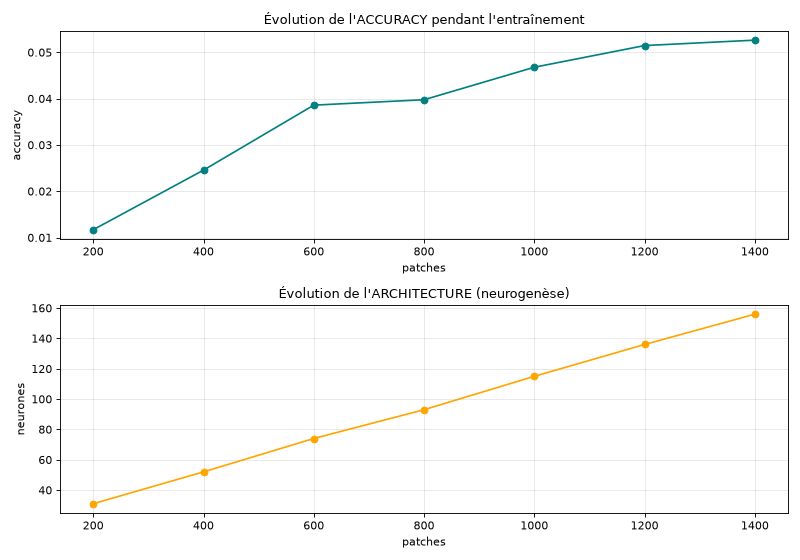

In [3]:
if acc_history:
    h = np.array(acc_history)
    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    axes[0].plot(h[:,0], h[:,1], 'o-', color='teal')
    axes[0].set_title("Évolution de l'ACCURACY pendant l'entraînement")
    axes[0].set_xlabel("patches"); axes[0].set_ylabel("accuracy"); axes[0].grid(alpha=0.3)
    axes[1].plot(h[:,0], h[:,2], 'o-', color='orange', label='neurones')
    axes[1].set_title("Évolution de l'ARCHITECTURE (neurogenèse)")
    axes[1].set_xlabel("patches"); axes[1].set_ylabel("neurones"); axes[1].grid(alpha=0.3)
    # marquer le spawn de couche
    for i,(np_,acc,nn,nl) in enumerate(acc_history):
        if nl > 1:
            axes[1].axvline(np_, color='crimson', ls='--', label='spawn C2' if i==0 else '')
    if any(r[3]>1 for r in acc_history): axes[1].legend()
    plt.tight_layout()
plt.savefig("__perf.png", dpi=80); plt.close()
display(IImg("__perf.png"))

## 3. Ce que les poids construisent (reconstruction)

On montre **ce que le modèle reconstruit à partir de ses poids** : pour chaque neurone, on affiche son prototype (le poids W). Ces prototypes sont ce que le modèle a appris à représenter.

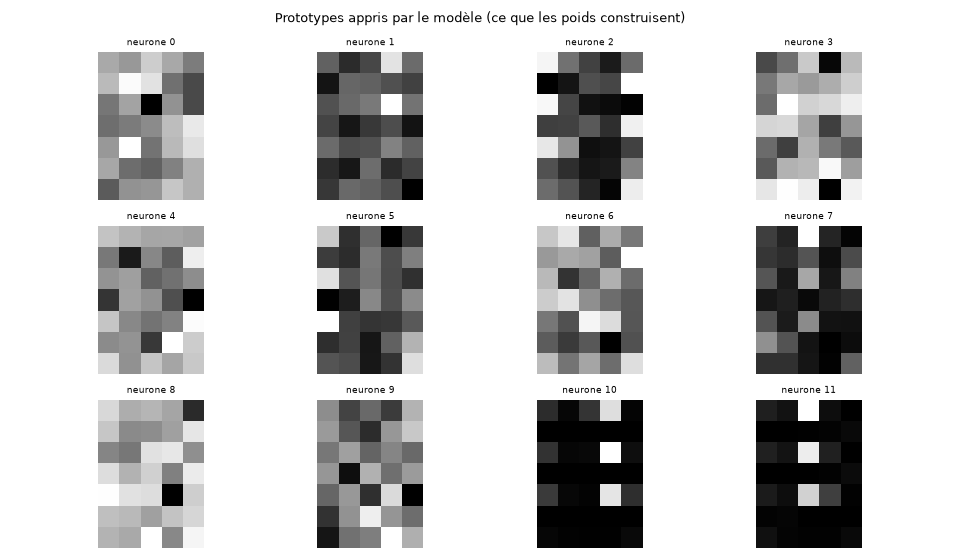

In [4]:
# afficher les prototypes des neurones de la couche finale
W = model.layer.W
n_show = min(12, len(W))
# chaque prototype est un vecteur de features (35 dims) — on les affiche comme images
fig, axes = plt.subplots(3, 4, figsize=(12, 7))
for k in range(n_show):
    proto = W[k]
    # normaliser et afficher comme image (7x5 approximé des 35 features)
    p = proto[:35].reshape(7,5)
    p = (p-p.min())/(p.max()-p.min()+1e-8)
    axes[k//4, k%4].imshow(p, cmap='gray')
    axes[k//4, k%4].set_title(f"neurone {k}", fontsize=8)
    axes[k//4, k%4].axis('off')
plt.suptitle("Prototypes appris par le modèle (ce que les poids construisent)")
plt.tight_layout()
plt.savefig("__proto.png", dpi=80); plt.close()
display(IImg("__proto.png"))

## 4. Architecture finale (couches + connexions)

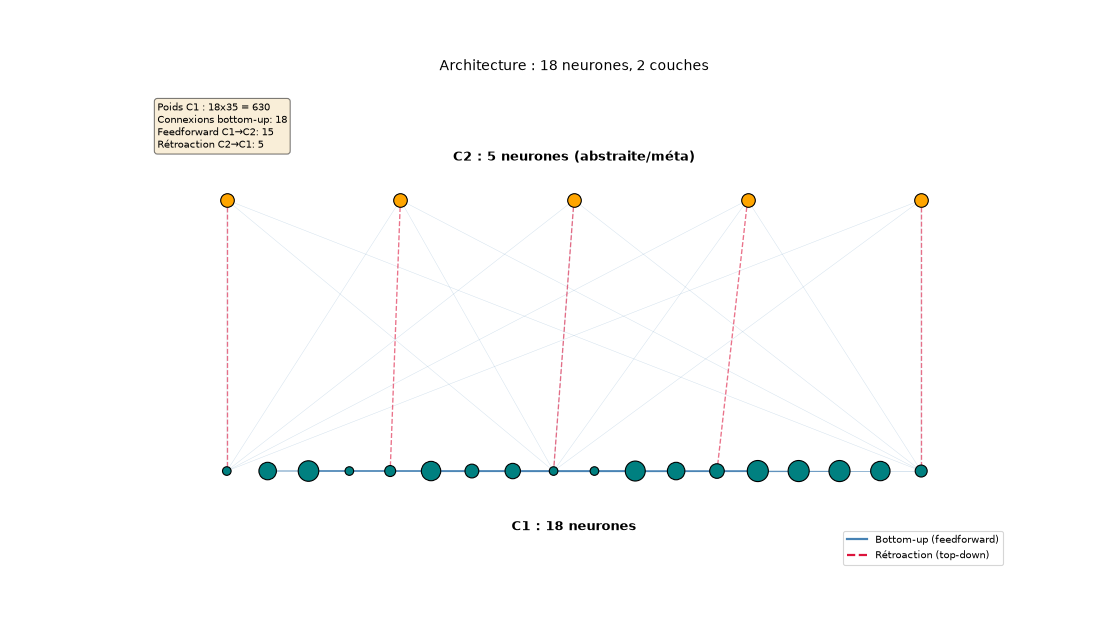

In [5]:
fig = draw_architecture(model.layer, title=f"Architecture : {model.layer.n_neurons_current} neurones, {model.controller.layer_count} couches")
plt.savefig("__archi.png", dpi=80); plt.close()
display(IImg("__archi.png"))

## 5. Analyse

In [6]:
print("=== ANALYSE : MONITORING COCO ===")
s = model.summary()
print(f"1. Neurogenèse PROGRESSIVE : 10 -> {s['neurons']} neurones (croissance douce)")
print(f"2. Spawn de couche : {s['layers']} couches, {s['archived_layers']} couche(s) archivée(s)")
print(f"3. Accuracy finale : {acc_history[-1][1]:.3f} si suivi, sinon voir courbe")
print()
print("=> Le modèle ÉVOLUE : il croît progressivement (neurogenèse), puis")
print("   créé une nouvelle couche quand la première est saturée. La courbe")
print("   d'accuracy montre si les performances progressent.")

=== ANALYSE : MONITORING COCO ===
1. Neurogenèse PROGRESSIVE : 10 -> 18 neurones (croissance douce)
2. Spawn de couche : 2 couches, 1 couche(s) archivée(s)
3. Accuracy finale : 0.053 si suivi, sinon voir courbe

=> Le modèle ÉVOLUE : il croît progressivement (neurogenèse), puis
   créé une nouvelle couche quand la première est saturée. La courbe
   d'accuracy montre si les performances progressent.
